In [ ]:
# Sprint 1: Exploratory Data Analysis
"""
Analysis of processed feature data across 6 seasons.
Key questions:
- How does tire degradation look across compounds?
- What is the label distribution?
- Are there correlations between features and pit decisions?
"""

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")

seasons = [2019, 2020, 2021, 2022, 2023, 2024]
processed_dir = Path("../data/processed")

dfs = []
for year in seasons:
    df = pd.read_csv(processed_dir / f"features_{year}.csv")
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(data)}")
print(f"Label distribution:\n{data['label'].value_counts()}")
print(f"Label ratio: {data['label'].mean():.3f}")

Total rows: 91077
Label distribution:
label
0    82803
1     8274
Name: count, dtype: int64
Label ratio: 0.091


In [ ]:
# label distribution per season
label_by_season = data.groupby("Year")["label"].agg(["sum", "count"])
label_by_season["ratio"] = (label_by_season["sum"] / label_by_season["count"] * 100).round(2)
label_by_season.columns = ["Pit Laps", "Total Laps", "Pit Ratio %"]
label_by_season

,Pit Laps,Total Laps,Pit Ratio %
Year,,,
2019,1526,18508,8.25
2020,1236,12921,9.57
2021,1345,16020,8.40
2022,1550,14949,10.37
2023,1309,14026,9.33
2024,1308,14653,8.93


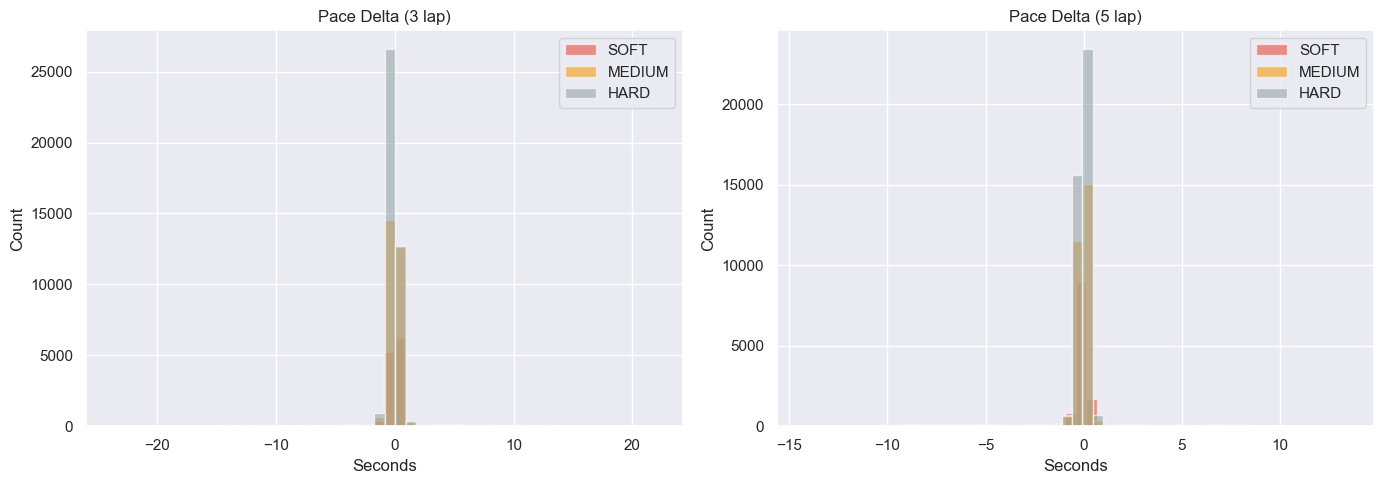

In [4]:
# pace degradation by compound
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

compound_names = {0: "SOFT", 1: "MEDIUM", 2: "HARD"}
colors = {0: "#e74c3c", 1: "#f39c12", 2: "#95a5a6"}

for compound_id, name in compound_names.items():
    subset = data[data["compound"] == compound_id]
    axes[0].hist(subset["pace_delta_3lap"].dropna(), bins=50, alpha=0.6,
                 label=name, color=colors[compound_id])
    axes[1].hist(subset["pace_delta_5lap"].dropna(), bins=50, alpha=0.6,
                 label=name, color=colors[compound_id])

axes[0].set_title("Pace Delta (3 lap)")
axes[1].set_title("Pace Delta (5 lap)")
for ax in axes:
    ax.set_xlabel("Seconds")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

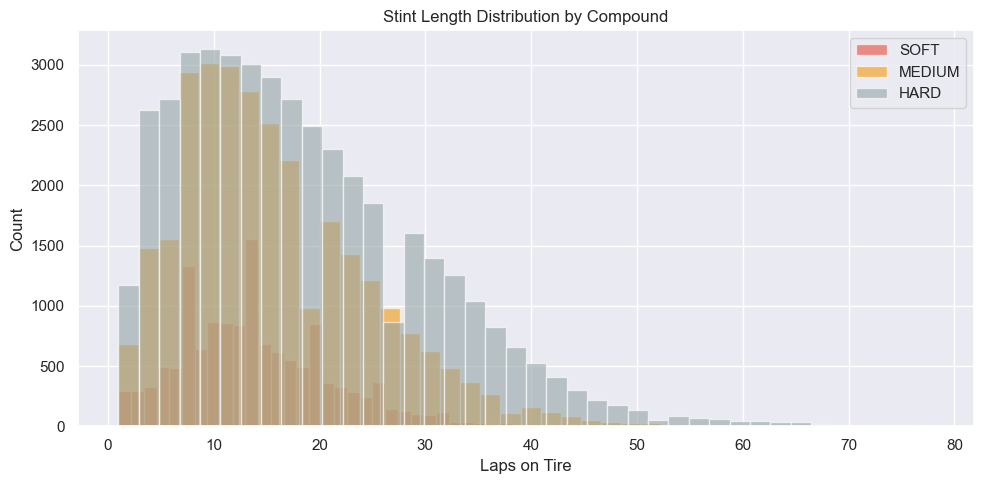

In [ ]:
# stint length distribution by compound
fig, ax = plt.subplots(figsize=(10, 5))

for compound_id, name in compound_names.items():
    subset = data[data["compound"] == compound_id]
    ax.hist(subset["stint_length"].dropna(), bins=40, alpha=0.6,
            label=name, color=colors[compound_id])

ax.set_title("Stint Length Distribution by Compound")
ax.set_xlabel("Laps on Tire")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

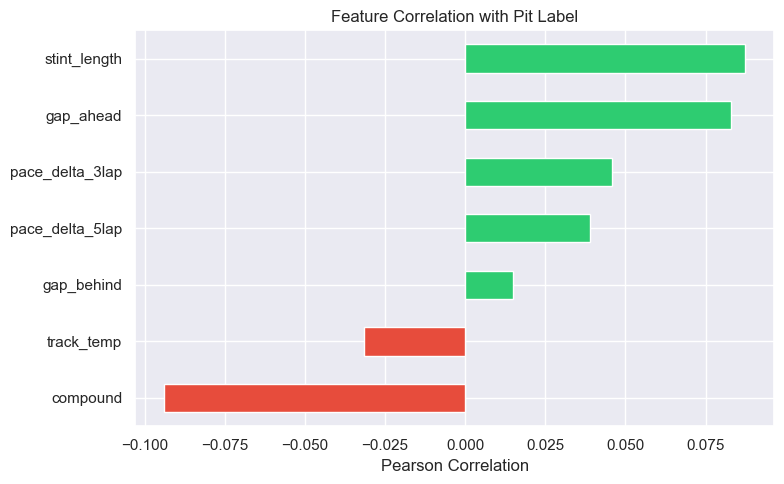

In [6]:
# feature correlation with label
numeric_cols = [
    "stint_length", "pace_delta_3lap", "pace_delta_5lap",
    "gap_ahead", "gap_behind", "track_temp", "compound"
]

correlations = data[numeric_cols + ["label"]].corr()["label"].drop("label").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind="barh", ax=ax, color=["#e74c3c" if x < 0 else "#2ecc71" for x in correlations])
ax.set_title("Feature Correlation with Pit Label")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

In [ ]:
## Key Findings
"""
- 91.077 total laps across 6 seasons (2019-2024)
- Label ratio consistent at ~9% across all seasons
- stint_length is the strongest predictor of pit decisions — tires degrade over time
- gap_ahead shows high correlation — undercut opportunity drives pit timing
- pace_delta features confirm that lap time degradation signals the pit window
- HARD compound negatively correlated — longer stints expected on harder tires
- track_temp negatively correlated — higher temperatures do not directly trigger earlier pits
"""